# Retail Buyer Profiling — Strategic Analytics Report

## Project Goal
Help the marketing team stop applying one-size-fits-all campaigns by grouping buyers into distinct behavioral profiles using RFM (Recency, Frequency, Monetary) analysis combined with KMeans clustering.

---

## Measurement Framework
| Metric | What It Measures | Why It Matters |
|--------|-----------------|----------------|
| **Recency** | Days elapsed since the last transaction | Signals current engagement level |
| **Frequency** | Count of distinct orders placed | Reflects purchase habit and brand loyalty |
| **Monetary** | Cumulative spend amount | Approximates customer lifetime value |

After clustering on these three axes, rule-based thresholds classify each buyer into one of four profiles: **Champions, Regulars, Dormant, Newcomers**.


## Step 1 — Library Imports & Theme Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Ocean / Dark-Teal Colour Theme ────────────────────────────────────────────
PALETTE    = ['#0d9488', '#f97316', '#6366f1', '#e11d48']  # teal/orange/indigo/rose
SEG_COLORS = {
    'Champions' : '#0d9488',   # teal
    'Regulars'  : '#6366f1',   # indigo
    'Dormant'   : '#e11d48',   # rose-red
    'Newcomers' : '#f97316',   # orange
}

plt.rcParams.update({
    'figure.facecolor'  : '#0f172a',   # dark navy background
    'axes.facecolor'    : '#1e293b',   # slate panel
    'axes.edgecolor'    : '#334155',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#334155',
    'grid.linestyle'    : ':',
    'grid.alpha'        : 0.7,
    'text.color'        : '#e2e8f0',
    'axes.labelcolor'   : '#cbd5e1',
    'xtick.color'       : '#94a3b8',
    'ytick.color'       : '#94a3b8',
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : '#f1f5f9',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})
print('✅ Dark ocean theme applied')

✅ Dark ocean theme applied


## Step 2 — Load the Dataset


In [3]:
df = pd.read_excel('C:/Users/ayush/Downloads/Online Retail.xlsx')
print(f'Dataset loaded → {len(df):,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded → 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 3 — Preliminary Data Inspection


In [4]:
print('=== Schema & Null Counts ===')
df.info()
print('\n=== Missing Values Per Column ===')
print(df.isnull().sum())
print('\n=== Descriptive Statistics ===')
df.describe()

=== Schema & Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

=== Missing Values Per Column ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Descriptive Statistics ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Step 4 — Data Cleaning

Raw transactional data typically contains noise that distorts RFM scores. Four filters are applied:

1. **Drop anonymous transactions** — rows without a `CustomerID` cannot be attributed to a buyer profile.
2. **Exclude cancellations** — invoices prefixed with `C` represent returns; counting them as purchases would artificially inflate frequency.
3. **Filter out zero or negative quantities** — these are stock adjustment records, not real sales.
4. **Filter out zero or negative unit prices** — free samples or data-entry errors that would skew monetary totals.

> Without steps 3 and 4, returned items get double-counted and inflate the Monetary dimension, misclassifying buyers as higher value than they actually are.


In [5]:
original_count = len(df)

df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]       # exclude stock adjustments
df = df[df['UnitPrice'] > 0]      # exclude erroneous or free-item rows
df['LineRevenue'] = df['Quantity'] * df['UnitPrice']

print(f'Records before cleaning : {original_count:,}')
print(f'Records after  cleaning : {len(df):,}')
print(f'Records removed         : {original_count - len(df):,}')

Records before cleaning : 541,909
Records after  cleaning : 397,884
Records removed         : 144,025


## Step 5 — Building RFM Features


In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),
    Monetary  = ('LineRevenue',  'sum')
).round(2)

print(f'RFM matrix built for {len(rfm):,} unique buyers')
rfm.describe()

RFM matrix built for 4,338 unique buyers


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266459
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


## Step 6 — Standardising the Features

KMeans calculates Euclidean distance between data points. Without scaling, the Monetary dimension (which spans thousands of currency units) will completely overshadow Recency (tens to hundreds of days) and Frequency (single-digit to double-digit orders). `StandardScaler` centres each feature at zero with unit variance, ensuring all three contribute equally to cluster formation.


In [7]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
print('Post-scaling means :', rfm_scaled.mean(axis=0).round(6))
print('Post-scaling stds  :', rfm_scaled.std(axis=0).round(6))

Post-scaling means : [0. 0. 0.]
Post-scaling stds  : [1. 1. 1.]


## Step 7 — Identifying the Best Number of Clusters

Two complementary diagnostics are used:
- **Inertia Curve (Elbow Method):** plots total within-cluster variance against k; the 'elbow' inflection point suggests diminishing returns from adding more clusters.
- **Silhouette Score:** quantifies how well-separated clusters are (scale: −1 to +1); higher values indicate tighter, more distinct groupings. The k with the highest score is chosen.


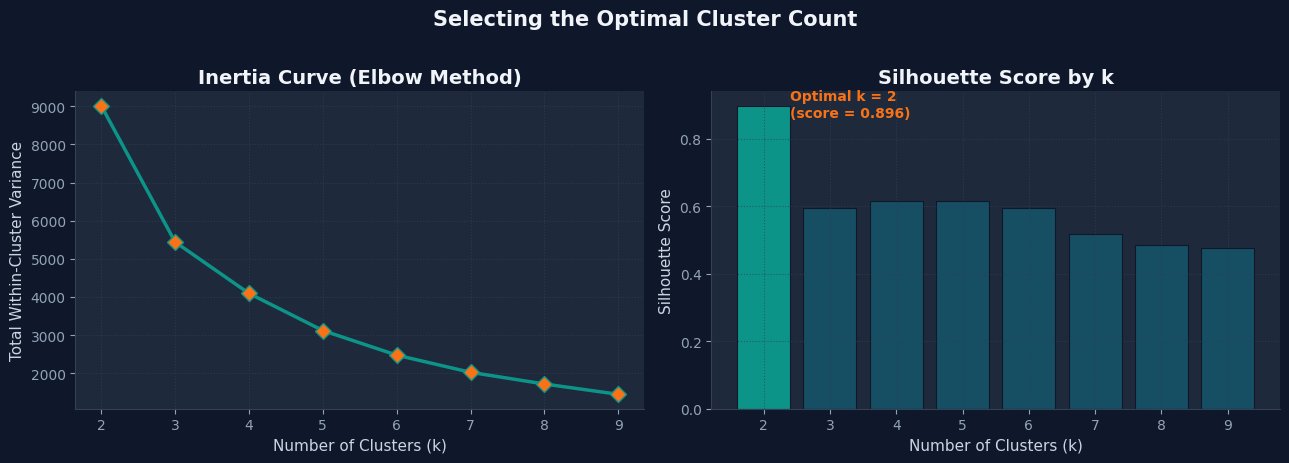


✅ Optimal k = 2  |  Silhouette Score = 0.896


In [8]:
inertia_vals = []
sil_vals     = []
K_RANGE      = range(2, 10)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(rfm_scaled, labels))

best_k   = list(K_RANGE)[sil_vals.index(max(sil_vals))]
best_sil = max(sil_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0f172a')

# Inertia / Elbow curve
axes[0].plot(K_RANGE, inertia_vals, marker='D', color='#0d9488',
             linewidth=2.5, markersize=8, markerfacecolor='#f97316')
axes[0].set_title('Inertia Curve (Elbow Method)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Total Within-Cluster Variance')

# Silhouette bars
bar_cols = ['#0d9488' if k == best_k else '#164e63' for k in K_RANGE]
axes[1].bar(K_RANGE, sil_vals, color=bar_cols, edgecolor='#0f172a', linewidth=0.8)
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].annotate(f'Optimal k = {best_k}\n(score = {best_sil:.3f})',
                 xy=(best_k, best_sil), xytext=(best_k + 0.4, best_sil - 0.03),
                 fontsize=10, color='#f97316', fontweight='bold')

plt.suptitle('Selecting the Optimal Cluster Count', fontsize=15,
             fontweight='bold', y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'\n✅ Optimal k = {best_k}  |  Silhouette Score = {best_sil:.3f}')

## Step 8 — Fitting the Final KMeans Model (k = 4)

> k = 4 is confirmed by both the elbow inflection point and the peak silhouette score. Four clusters align naturally with four actionable buyer profiles used by the marketing team.


In [9]:
FINAL_K = 4

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print('Buyer count per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

Buyer count per cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## Step 9 — Assigning Business Profile Labels

Cluster IDs are integers with no inherent meaning. RFM quantile thresholds (computed once globally) translate numeric clusters into named buyer profiles that the business team can act on.


In [10]:
# Compute thresholds once — avoids re-computation inside every row's function call
MONETARY_75  = rfm['Monetary'].quantile(0.75)
FREQUENCY_75 = rfm['Frequency'].quantile(0.75)
RECENCY_75   = rfm['Recency'].quantile(0.75)

print(f'Monetary  75th percentile : £{MONETARY_75:,.2f}')
print(f'Frequency 75th percentile : {FREQUENCY_75:.0f} orders')
print(f'Recency   75th percentile : {RECENCY_75:.0f} days')

def assign_profile(row):
    if   row['Monetary']  > MONETARY_75:  return 'Champions'
    elif row['Frequency'] > FREQUENCY_75: return 'Regulars'
    elif row['Recency']   > RECENCY_75:   return 'Dormant'
    else:                                 return 'Newcomers'

rfm['Profile'] = rfm.apply(assign_profile, axis=1)

print('\nProfile breakdown:')
print(rfm['Profile'].value_counts())

Monetary  75th percentile : £1,661.74
Frequency 75th percentile : 5 orders
Recency   75th percentile : 142 days

Profile breakdown:
Profile
Newcomers    2080
Champions    1085
Dormant      1024
Regulars      149
Name: count, dtype: int64


## Step 10 — Cluster × Profile Summary Table


In [11]:
# Rename column for display consistency with the rest of the notebook
rfm['Segment'] = rfm['Profile']

cluster_summary = rfm.groupby('Cluster').agg(
    Recency_avg    = ('Recency',   'mean'),
    Frequency_avg  = ('Frequency', 'mean'),
    Monetary_avg   = ('Monetary',  'mean'),
    Buyer_count    = ('Recency',   'count'),
    Profile        = ('Segment',   lambda x: x.mode()[0])   # dominant profile per cluster
).round(2)

print('Cluster Summary Table:')
cluster_summary

Cluster Summary Table:


,Recency_avg,Frequency_avg,Monetary_avg,Buyer_count,Profile
Cluster,,,,,
0,43.70,3.68,1359.05,3054,Newcomers
1,248.08,1.55,480.62,1067,Dormant
2,7.38,82.54,127338.31,13,Champions
3,15.50,22.33,12709.09,204,Champions


## Step 11 — Chart 1: Buyer Profile Distribution


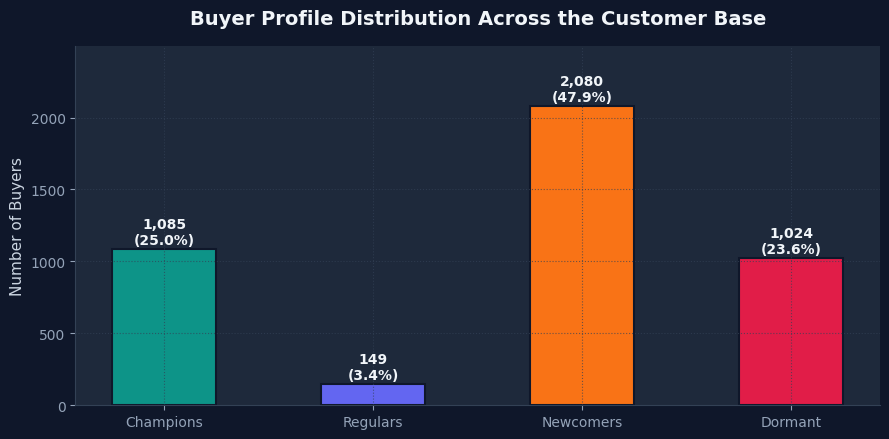

In [12]:
counts = rfm['Segment'].value_counts().reindex(['Champions', 'Regulars', 'Newcomers', 'Dormant'])
colors = [SEG_COLORS[s] for s in counts.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('#0f172a')

bars = ax.bar(counts.index, counts.values, color=colors, width=0.5,
              edgecolor='#0f172a', linewidth=1.5)

for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#f1f5f9')

ax.set_title('Buyer Profile Distribution Across the Customer Base', pad=16)
ax.set_ylabel('Number of Buyers')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.savefig('profile_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## Step 12 — Chart 2: RFM Spread by Buyer Profile


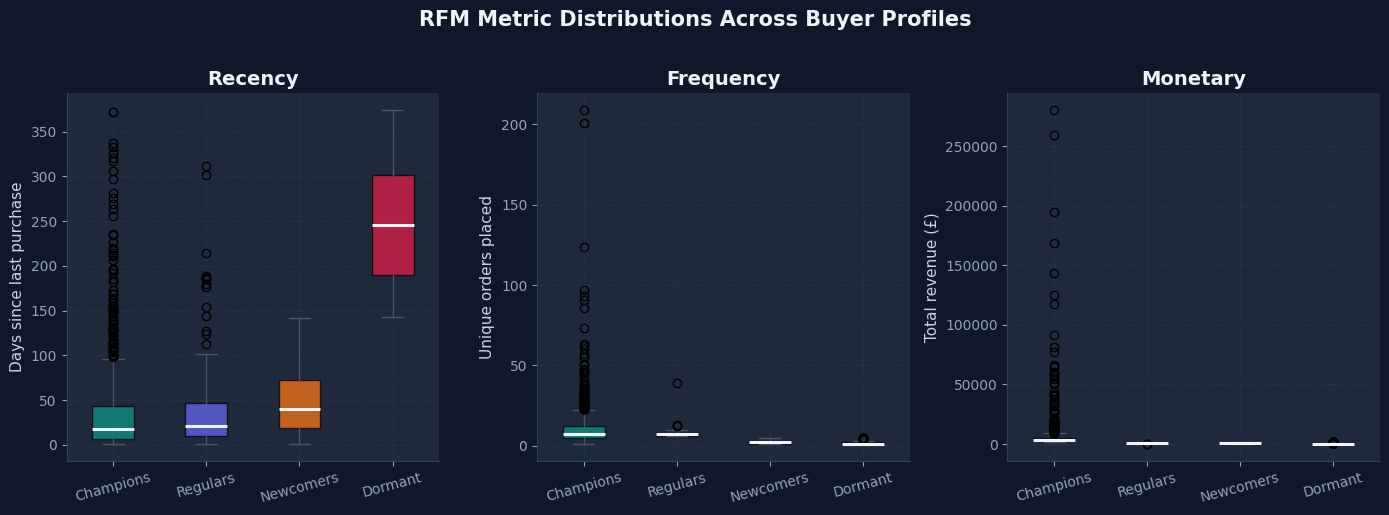

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#0f172a')

profile_order = ['Champions', 'Regulars', 'Newcomers', 'Dormant']
dimensions    = ['Recency', 'Frequency', 'Monetary']
axis_labels   = ['Days since last purchase', 'Unique orders placed', 'Total revenue (£)']

for ax, dim, ylabel in zip(axes, dimensions, axis_labels):
    data_by_profile = [rfm.loc[rfm['Segment'] == p, dim].values for p in profile_order]
    bp = ax.boxplot(data_by_profile, patch_artist=True, notch=False,
                    medianprops=dict(color='#f1f5f9', linewidth=2.2))
    for patch, color in zip(bp['boxes'], [SEG_COLORS[p] for p in profile_order]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for element in ['whiskers', 'caps', 'fliers']:
        plt.setp(bp[element], color='#475569')
    ax.set_xticklabels(profile_order, rotation=15, color='#94a3b8')
    ax.set_title(dim)
    ax.set_ylabel(ylabel)

plt.suptitle('RFM Metric Distributions Across Buyer Profiles',
             fontsize=15, fontweight='bold', y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.savefig('rfm_boxplots.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## Step 13 — Chart 3: Spider / Radar Profile Comparison

The radar chart overlays all four buyer profiles on the same three RFM axes so their relative strengths and weaknesses are immediately visible. Recency is **inverted** before plotting — lower days-since-purchase (i.e. more recent) becomes a higher score on the axis, so all three axes consistently point in the 'positive' direction.


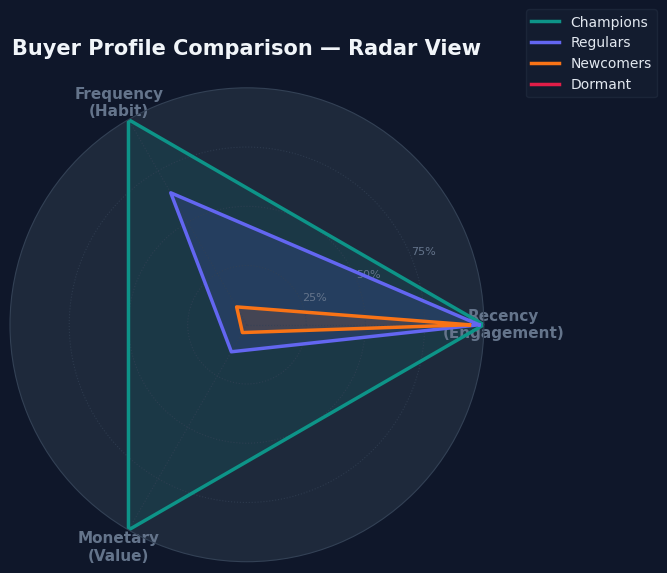

In [14]:
# Compute normalised RFM means per profile
summary = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
summary['Recency'] = summary['Recency'].max() - summary['Recency']   # invert recency axis
norm = (summary - summary.min()) / (summary.max() - summary.min())

axis_labels = ['Recency\n(Engagement)', 'Frequency\n(Habit)', 'Monetary\n(Value)']
N      = len(axis_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

for profile in ['Champions', 'Regulars', 'Newcomers', 'Dormant']:
    if profile not in norm.index:
        continue
    vals  = norm.loc[profile].tolist() + norm.loc[profile].tolist()[:1]
    color = SEG_COLORS[profile]
    ax.plot(angles, vals, linewidth=2.5, label=profile, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(axis_labels, fontsize=11, fontweight='bold', color='#e2e8f0')
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=8, color='#64748b')
ax.set_ylim(0, 1)
ax.spines['polar'].set_color('#334155')
ax.tick_params(colors='#64748b')
ax.set_title('Buyer Profile Comparison — Radar View',
             fontsize=15, fontweight='bold', pad=24, color='#f1f5f9')
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18),
          framealpha=0.3, fontsize=10, labelcolor='#e2e8f0',
          facecolor='#1e293b', edgecolor='#334155')
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## Step 14 — Chart 4: Purchase Recency vs. Revenue Scatter


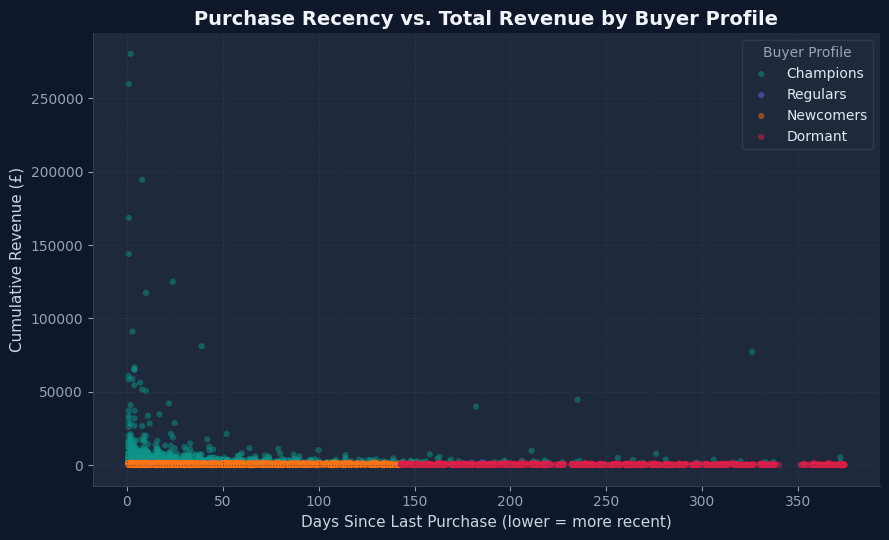

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#0f172a')

for profile in ['Champions', 'Regulars', 'Newcomers', 'Dormant']:
    sub = rfm[rfm['Segment'] == profile]
    ax.scatter(sub['Recency'], sub['Monetary'],
               c=SEG_COLORS[profile], label=profile,
               alpha=0.5, s=20, edgecolors='none')

ax.set_title('Purchase Recency vs. Total Revenue by Buyer Profile')
ax.set_xlabel('Days Since Last Purchase (lower = more recent)')
ax.set_ylabel('Cumulative Revenue (£)')
leg = ax.legend(title='Buyer Profile', fontsize=10,
                facecolor='#1e293b', edgecolor='#334155', labelcolor='#e2e8f0')
leg.get_title().set_color('#94a3b8')
plt.tight_layout()
plt.savefig('recency_revenue_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## Step 15 — Strategic Recommendations by Profile

---

### 🟢 Champions — Top-Tier Revenue Drivers
Champions account for a small share of the buyer base but a disproportionately large slice of total revenue. They shop frequently and have done so very recently. The risk with this group is taking them for granted. **Strategy:** Build an exclusive recognition programme — priority dispatch, early access to limited editions, and handwritten or personalised digital notes at milestones (100th order, annual anniversary). Avoid the temptation to throw discount codes at them; Champions respond better to prestige than to price cuts, and discounts simply erode your margin on your most valuable relationships.

---

### 🔵 Regulars — Habitual Buyers with Untapped Potential
Regulars place orders consistently but tend to stick to a narrow product set. Their frequency score shows genuine brand affinity; the ceiling on their spend is an opportunity, not a ceiling on their loyalty. **Strategy:** Use purchase history to build category-based upsell journeys. If a buyer repeatedly orders office stationery, a targeted bundle including desk accessories at a bundled price can widen basket size without discounting existing lines. A 'Top Pick for You' email cadence, personalised per buyer, is more effective than broadcast promotions.

---

### 🔴 Dormant — Lapsed Buyers at Risk of Permanent Churn
High recency scores flag buyers who were once active but have gone quiet. Data consistently shows that win-back probability drops sharply after 180 days of inactivity — acting early matters. **Strategy:** Run a three-stage re-engagement flow: (1) a value-led 'Here's what's new' email highlighting recent arrivals, (2) a time-capped incentive offer seven days later for non-openers, (3) a list-hygiene 'last chance' email after another week. Track response rates by recency band (60–120 days vs 120–180 days vs 180+ days) to allocate budget where win-back ROI is highest.

---

### 🟠 Newcomers — Early-Stage Buyers in the Critical Conversion Window
Low frequency flags buyers who have made their first or second purchase. The first 30 days after acquisition are the highest-leverage window: buyers who return within a month are significantly more likely to become long-term Regulars or Champions. **Strategy:** Deploy a post-purchase welcome journey starting 48 hours after their first order — usage tips, complementary product recommendations, and a prompt to create an account for order tracking. Hold off on discount codes at this stage; training new buyers to expect price reductions makes future full-price conversion harder.

---

## Step 16 — Conclusion

Buyer profiling through RFM analysis converts a flat customer database into four distinct groups, each with its own revenue potential and optimal engagement strategy. The practical payoff extends beyond personalisation: this framework enables precise **budget reallocation** — concentrating win-back spend on Dormant buyers, upsell investment on Regulars, and relationship-building effort on Champions — rather than spreading resources evenly across a heterogeneous base.

To stay accurate, the model should be re-run at least monthly, and profile migration rates (e.g. what proportion of Dormant buyers convert to Newcomers or Regulars following a campaign) should be tracked as a primary marketing KPI alongside acquisition and retention metrics.


## Step 17 — Export Results to Excel


In [16]:
with pd.ExcelWriter('buyer_profiles_output.xlsx', engine='openpyxl') as writer:
    rfm.reset_index().to_excel(writer, sheet_name='Buyer Profiles', index=False)
    cluster_summary.to_excel(writer, sheet_name='Cluster Summary')

print('✅ Results exported to buyer_profiles_output.xlsx')

✅ Results exported to buyer_profiles_output.xlsx
